In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


df  = pd.read_csv(
    r"C:\Users\IVAN\Desktop\ML обучение с Gemini\Файлы\House Prices - Advanced Regression Techniques\train.csv",
    sep=","
)

X_test = pd.read_csv(
    r"C:\Users\IVAN\Desktop\ML обучение с Gemini\Файлы\House Prices - Advanced Regression Techniques\test.csv",
    sep=","
)

df.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [14]:
# 1 Первичный анализ
# 1)
cols = df.columns.tolist()
cat_cols = df[cols].select_dtypes(exclude=['number']).columns.tolist()
num_cols = df[cols].select_dtypes(include=['number']).columns.tolist()
print(len(cat_cols), len(num_cols))
print('Train', df.shape)
print('Test', X_test.shape)
num_cols = num_cols[:-1]

43 38
Train (1460, 81)
Test (1459, 80)


In [15]:
# 2)
print(df['SalePrice'].describe())
print(df['SalePrice'].skew())
# думаю стоит прологарифмировать,распределение перекошено вправо, 
# максимум в семи межквартильных размахах от медианы

count      1460.000000
mean     180921.195890
std       79442.502883
min       34900.000000
25%      129975.000000
50%      163000.000000
75%      214000.000000
max      755000.000000
Name: SalePrice, dtype: float64
1.8828757597682129


In [16]:
# 3)
# процент пропусков в каждой колонке
miss_cols = df.isna().mean() * 100 

cols_with_nan = miss_cols[miss_cols > 0]

top_nan = cols_with_nan.sort_values(ascending=False)

print(top_nan)

PoolQC          99.520548
MiscFeature     96.301370
Alley           93.767123
Fence           80.753425
MasVnrType      59.726027
FireplaceQu     47.260274
LotFrontage     17.739726
GarageType       5.547945
GarageYrBlt      5.547945
GarageFinish     5.547945
GarageQual       5.547945
GarageCond       5.547945
BsmtExposure     2.602740
BsmtFinType2     2.602740
BsmtQual         2.534247
BsmtCond         2.534247
BsmtFinType1     2.534247
MasVnrArea       0.547945
Electrical       0.068493
dtype: float64


In [17]:
# 4)
# numeric_df = df[num_cols]

# numeric_df_corr = numeric_df.corr()
# top_5_corr = (
#     numeric_df_corr['SalePrice']
#     .drop('SalePrice')
#     .abs()
#     .sort_values(ascending=False)
#     .head(5)
#     )

# top_5_features = numeric_df_corr['SalePrice'].loc[top_5_corr.index]

# print('Топ 5 признаков коррелирующих с SalePrice')
# print(top_5_features)


In [18]:
# 2 Очистка данных
# 1)
X = df.drop(columns=['SalePrice'])
y = df['SalePrice']

y = np.log1p(y)

In [19]:
# 2)

special_na_cols = ['PoolQC', 'MiscFeature', 'Alley', 'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2', 'FireplaceQu', 'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond', 'Fence']

for col in cat_cols:
    if col in special_na_cols:
        X[col] = X[col].fillna('NO')
        X_test[col] = X_test[col].fillna('NO')
    else:
        mode = X[col].mode()[0]
        X[col] = X[col].fillna(mode)
        X_test[col] = X_test[col].fillna(mode)

X.head(10)

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition
0,1,60,RL,65.0,8450,Pave,NO,Reg,Lvl,AllPub,...,0,0,NO,NO,NO,0,2,2008,WD,Normal
1,2,20,RL,80.0,9600,Pave,NO,Reg,Lvl,AllPub,...,0,0,NO,NO,NO,0,5,2007,WD,Normal
2,3,60,RL,68.0,11250,Pave,NO,IR1,Lvl,AllPub,...,0,0,NO,NO,NO,0,9,2008,WD,Normal
3,4,70,RL,60.0,9550,Pave,NO,IR1,Lvl,AllPub,...,0,0,NO,NO,NO,0,2,2006,WD,Abnorml
4,5,60,RL,84.0,14260,Pave,NO,IR1,Lvl,AllPub,...,0,0,NO,NO,NO,0,12,2008,WD,Normal
5,6,50,RL,85.0,14115,Pave,NO,IR1,Lvl,AllPub,...,0,0,NO,MnPrv,Shed,700,10,2009,WD,Normal
6,7,20,RL,75.0,10084,Pave,NO,Reg,Lvl,AllPub,...,0,0,NO,NO,NO,0,8,2007,WD,Normal
7,8,60,RL,NaN,10382,Pave,NO,IR1,Lvl,AllPub,...,0,0,NO,NO,Shed,350,11,2009,WD,Normal
8,9,50,RM,51.0,6120,Pave,NO,Reg,Lvl,AllPub,...,0,0,NO,NO,NO,0,4,2008,WD,Abnorml
9,10,190,RL,50.0,7420,Pave,NO,Reg,Lvl,AllPub,...,0,0,NO,NO,NO,0,1,2008,WD,Normal


In [20]:
# 3)
from sklearn.preprocessing import OrdinalEncoder

ohe_cat_cols = ['MSZoning', 'Street', 'Utilities', 'LotConfig', 
                'Neighborhood', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle', 
                'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType', 
                'Foundation', 'Heating', 'CentralAir', 'Electrical', 'Functional',
                'GarageType', 'MiscFeature', 'SaleType', 'SaleCondition']


X = pd.get_dummies(X, columns=ohe_cat_cols, drop_first=True, dtype=int)
X_test = pd.get_dummies(X_test, columns=ohe_cat_cols, drop_first=True, dtype=int)
X, X_test = X.align(X_test, join='left', axis=1, fill_value=0)

encoder = OrdinalEncoder(categories=[['Lvl', 'Bnk', 'HLS', 'Low']])
X['LandContour'] = encoder.fit_transform(X[['LandContour']])
X_test['LandContour'] = encoder.transform(X_test[['LandContour']])

encoder = OrdinalEncoder(categories=[['IR3', 'IR2', 'IR1', 'Reg']])
X['LotShape'] = encoder.fit_transform(X[['LotShape']])
X_test['LotShape'] = encoder.transform(X_test[['LotShape']])

encoder = OrdinalEncoder(categories=[['NO', 'Grvl', 'Pave']])
X['Alley'] = encoder.fit_transform(X[['Alley']])
X_test['Alley'] = encoder.transform(X_test[['Alley']])

encoder = OrdinalEncoder(categories=[['Gtl', 'Mod', 'Sev']])
X['LandSlope'] = encoder.fit_transform(X[['LandSlope']])
X_test['LandSlope'] = encoder.transform(X_test[['LandSlope']])

encoder = OrdinalEncoder(categories=[['Po', 'Fa', 'TA', 'Gd', 'Ex']])
X['ExterQual'] = encoder.fit_transform(X[['ExterQual']])
X_test['ExterQual'] = encoder.transform(X_test[['ExterQual']])

encoder = OrdinalEncoder(categories=[['Po', 'Fa', 'TA', 'Gd', 'Ex']])
X['ExterCond'] = encoder.fit_transform(X[['ExterCond']])
X_test['ExterCond'] = encoder.transform(X_test[['ExterCond']])

encoder = OrdinalEncoder(categories=[['NO', 'Po', 'Fa', 'TA', 'Gd', 'Ex']])
X['BsmtQual'] = encoder.fit_transform(X[['BsmtQual']])
X_test['BsmtQual'] = encoder.transform(X_test[['BsmtQual']])

encoder = OrdinalEncoder(categories=[['NO', 'Po', 'Fa', 'TA', 'Gd', 'Ex']])
X['BsmtCond'] = encoder.fit_transform(X[['BsmtCond']])
X_test['BsmtCond'] = encoder.transform(X_test[['BsmtCond']])

encoder = OrdinalEncoder(categories=[['NO', 'No', 'Mn', 'Av', 'Gd']])
X['BsmtExposure'] = encoder.fit_transform(X[['BsmtExposure']])
X_test['BsmtExposure'] = encoder.transform(X_test[['BsmtExposure']])

encoder = OrdinalEncoder(categories=[['NO', 'Unf', 'LwQ', 'Rec', 'BLQ', 'ALQ', 'GLQ']])
X['BsmtFinType1'] = encoder.fit_transform(X[['BsmtFinType1']])
X_test['BsmtFinType1'] = encoder.transform(X_test[['BsmtFinType1']])

encoder = OrdinalEncoder(categories=[['NO', 'Unf', 'LwQ', 'Rec', 'BLQ', 'ALQ', 'GLQ']])
X['BsmtFinType2'] = encoder.fit_transform(X[['BsmtFinType2']])
X_test['BsmtFinType2'] = encoder.transform(X_test[['BsmtFinType2']])

encoder = OrdinalEncoder(categories=[['Po', 'Fa', 'TA', 'Gd', 'Ex']])
X['HeatingQC'] = encoder.fit_transform(X[['HeatingQC']])
X_test['HeatingQC'] = encoder.transform(X_test[['HeatingQC']])

encoder = OrdinalEncoder(categories=[['Po', 'Fa', 'TA', 'Gd', 'Ex']])
X['KitchenQual'] = encoder.fit_transform(X[['KitchenQual']])
X_test['KitchenQual'] = encoder.transform(X_test[['KitchenQual']])

encoder = OrdinalEncoder(categories=[['NO', 'Po', 'Fa', 'TA', 'Gd', 'Ex']])
X['FireplaceQu'] = encoder.fit_transform(X[['FireplaceQu']])
X_test['FireplaceQu'] = encoder.transform(X_test[['FireplaceQu']])

encoder = OrdinalEncoder(categories=[['NO', 'Unf', 'RFn', 'Fin']])
X['GarageFinish'] = encoder.fit_transform(X[['GarageFinish']])
X_test['GarageFinish'] = encoder.transform(X_test[['GarageFinish']])

encoder = OrdinalEncoder(categories=[['NO', 'Po', 'Fa', 'TA', 'Gd', 'Ex']])
X['GarageQual'] = encoder.fit_transform(X[['GarageQual']])
X_test['GarageQual'] = encoder.transform(X_test[['GarageQual']])

encoder = OrdinalEncoder(categories=[['NO', 'Po', 'Fa', 'TA', 'Gd', 'Ex']])
X['GarageCond'] = encoder.fit_transform(X[['GarageCond']])
X_test['GarageCond'] = encoder.transform(X_test[['GarageCond']])

encoder = OrdinalEncoder(categories=[['N', 'P', 'Y']])
X['PavedDrive'] = encoder.fit_transform(X[['PavedDrive']])
X_test['PavedDrive'] = encoder.transform(X_test[['PavedDrive']])

encoder = OrdinalEncoder(categories=[['NO', 'Fa', 'TA', 'Gd', 'Ex']])
X['PoolQC'] = encoder.fit_transform(X[['PoolQC']])
X_test['PoolQC'] = encoder.transform(X_test[['PoolQC']])

encoder = OrdinalEncoder(categories=[['NO', 'MnWw', 'GdWo', 'MnPrv', 'GdPrv']])
X['Fence'] = encoder.fit_transform(X[['Fence']])
X_test['Fence'] = encoder.transform(X_test[['Fence']])

X.head()

,Id,MSSubClass,LotFrontage,LotArea,Alley,LotShape,LandContour,LandSlope,OverallQual,OverallCond,...,SaleType_ConLI,SaleType_ConLw,SaleType_New,SaleType_Oth,SaleType_WD,SaleCondition_AdjLand,SaleCondition_Alloca,SaleCondition_Family,SaleCondition_Normal,SaleCondition_Partial
0,1,60,65.0,8450,0.0,3.0,0.0,0.0,7,5,...,0,0,0,0,1,0,0,0,1,0
1,2,20,80.0,9600,0.0,3.0,0.0,0.0,6,8,...,0,0,0,0,1,0,0,0,1,0
2,3,60,68.0,11250,0.0,2.0,0.0,0.0,7,5,...,0,0,0,0,1,0,0,0,1,0
3,4,70,60.0,9550,0.0,2.0,0.0,0.0,7,5,...,0,0,0,0,1,0,0,0,0,0
4,5,60,84.0,14260,0.0,2.0,0.0,0.0,8,5,...,0,0,0,0,1,0,0,0,1,0


<Axes: xlabel='GrLivArea', ylabel='SalePrice'>

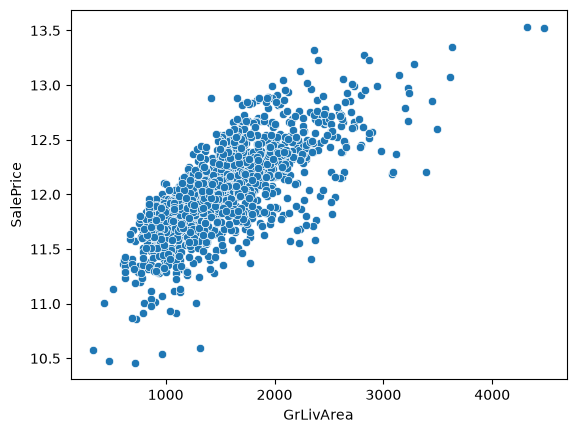

In [21]:
# 4
# sns.scatterplot(x=X['GrLivArea'], y=y)
outliers_mask = ~((X["GrLivArea"] > 4000) & (y < 12.5))

X = X[outliers_mask]
y = y[outliers_mask]

sns.scatterplot(x=X['GrLivArea'], y=y)

In [22]:
# 3 Пропуски в численных столбцах и масштабирование
from sklearn.preprocessing import StandardScaler
# X_test это файл test.csv с Kaggle

for col in num_cols:
    med = X[col].median()
    X[col] = X[col].fillna(med)
    X_test[col] = X_test[col].fillna(med)

X['HouseAge'] = X['YrSold'] - X['YearBuilt']
X_test['HouseAge'] = X_test['YrSold'] - X_test['YearBuilt']

X['HouseS'] = X['1stFlrSF'] + X['2ndFlrSF']
X_test['HouseS'] = X_test['1stFlrSF'] + X_test['2ndFlrSF']

X['RemodAge'] = X['YrSold'] - X['YearRemodAdd']
X_test['RemodAge'] = X_test['YrSold'] - X_test['YearRemodAdd']

num_cols.extend(['HouseAge', 'HouseS', 'RemodAge'])

X = X.drop(columns=['YrSold', 'YearBuilt', '1stFlrSF', '2ndFlrSF', 'YearRemodAdd'])
X_test = X_test.drop(columns=['YrSold', 'YearBuilt', '1stFlrSF', '2ndFlrSF', 'YearRemodAdd'])

for col in ['YrSold', 'YearBuilt', '1stFlrSF', '2ndFlrSF', 'YearRemodAdd']:
    num_cols.remove(col)

for col in num_cols[1:]: # 0 - ID
    if abs(X[col].skew()) > 1:

        X[col] = np.log1p(X[col])
        X_test[col] = np.log1p(X_test[col])

scaler = StandardScaler()

X[num_cols[1:]] = scaler.fit_transform(X[num_cols[1:]])
X_test[num_cols[1:]] = scaler.transform(X_test[num_cols[1:]])

X.head()

,Id,MSSubClass,LotFrontage,LotArea,Alley,LotShape,LandContour,LandSlope,OverallQual,OverallCond,...,SaleType_Oth,SaleType_WD,SaleCondition_AdjLand,SaleCondition_Alloca,SaleCondition_Family,SaleCondition_Normal,SaleCondition_Partial,HouseAge,HouseS,RemodAge
0,1,0.424806,-0.074782,-0.129624,0.0,3.0,0.0,0.0,0.658506,-0.517649,...,0,1,0,0,0,1,0,-1.045249,0.408183,-0.871676
1,2,-1.123988,0.582792,0.118819,0.0,3.0,0.0,0.0,-0.068293,2.177825,...,0,1,0,0,0,1,0,-0.185182,-0.482166,0.388660
2,3,0.424806,0.067948,0.427643,0.0,2.0,0.0,0.0,0.658506,-0.517649,...,0,1,0,0,0,1,0,-0.979090,0.559224,-0.823201
3,4,0.645292,-0.327739,0.108651,0.0,2.0,0.0,0.0,0.658506,-0.517649,...,0,1,0,0,0,0,0,1.799589,0.422094,0.631032
4,5,0.424806,0.737564,0.889295,0.0,2.0,0.0,0.0,1.385305,-0.517649,...,0,1,0,0,0,1,0,-0.946011,1.378027,-0.726252


In [23]:
# 4 Обучение моделей
# 1) бейзлайн
from sklearn.linear_model import LinearRegression, RidgeCV, LassoCV
from sklearn.model_selection import cross_val_score

model = LinearRegression()

X_no_id = X.drop(columns=['Id'])
X_no_id_sq = (X_no_id ** 2).add_suffix('^2')
X_no_id = pd.concat([X_no_id, X_no_id_sq], axis=1)

neg_rmse_scores = cross_val_score(model, X_no_id, y, cv=5, scoring='neg_root_mean_squared_error')
rmse_scores = -neg_rmse_scores

print(rmse_scores.mean())

0.12570656787810178


In [24]:
# 2) Регуляризации

alphas_ridge = np.logspace(-1, 3, 200)
alphas_lasso = np.logspace(-5, -2, 300)
ridge_cv = RidgeCV(alphas=alphas_ridge, cv=5)
lasso_cv = LassoCV(alphas=alphas_lasso, cv=5)

ridge_cv.fit(X_no_id, y)
lasso_cv.fit(X_no_id, y)

print(ridge_cv.alpha_)
print(lasso_cv.alpha_)

c:\Users\IVAN\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:825: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.111737e-02, tolerance: 1.891e-02
  model = cd_fast.enet_coordinate_descent_gram(
c:\Users\IVAN\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:825: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.216356e-02, tolerance: 1.891e-02
  model = cd_fast.enet_coordinate_descent_gram(
c:\Users\IVAN\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:825: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, 

23.54286414322418
0.000639764395574843


c:\Users\IVAN\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:825: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.556423e-02, tolerance: 1.881e-02
  model = cd_fast.enet_coordinate_descent_gram(
c:\Users\IVAN\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:825: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.473078e-02, tolerance: 1.881e-02
  model = cd_fast.enet_coordinate_descent_gram(


In [25]:
from sklearn.linear_model import Ridge, Lasso

ridge_best = Ridge(alpha=ridge_cv.alpha_)
lasso_best = Lasso(alpha=lasso_cv.alpha_)

ridge_scores = cross_val_score(ridge_best, X_no_id, y, cv=5, scoring='neg_root_mean_squared_error')
lasso_scores = cross_val_score(lasso_best, X_no_id, y, cv=5, scoring='neg_root_mean_squared_error')

print((-ridge_scores).mean())
print((-lasso_scores).mean())

0.11267530387973605
0.1117870463513702


In [ ]:
# 3) обратная трансформация и сабмит
X_test_no_id = X_test.drop(columns=['Id'])
X_test_no_id_sq = (X_test_no_id ** 2).add_suffix('^2')
X_test_no_id = pd.concat([X_test_no_id, X_test_no_id_sq], axis=1)

lasso_best.fit(X_no_id, y)

y_pred = np.expm1(lasso_best.predict(X_test_no_id))

submission = pd.DataFrame({
    'Id' : X_test['Id'],
    'SalePrice' : y_pred 
})

submission.head()

submission.to_csv(r'C:\Users\IVAN\Desktop\ML обучение с Gemini\Файлы\House Prices - Advanced Regression Techniques\submission.csv', index=False)